### Time Series Plots

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Note: Replace 'your_data.csv' with the path to your dataset

train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_synthetic_train_small.csv"
# test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_sim_test.csv"
# train_data = pd.read_csv(train_file_path)
# test_data = pd.read_csv(test_file_path)

df = pd.read_csv(train_file_path)
df.head()


,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,...,M1371,M1372,M1373,M1374,M1375,M1376,M1377,M1378,M1379,Label
0,328,325,319,323,322,322,327,324,329,322,...,960,955,989,951,970,1090,980,958,972,0
1,314,324,328,325,319,323,322,322,327,324,...,830,815,960,955,989,951,970,1090,980,1
2,431,428,431,429,426,424,419,301,301,303,...,823,1004,945,938,948,939,943,936,1040,0
3,332,327,327,329,332,327,328,318,329,329,...,983,991,944,687,408,443,422,412,402,0
4,692,687,684,688,683,684,812,820,806,803,...,337,376,388,413,564,547,543,541,544,0


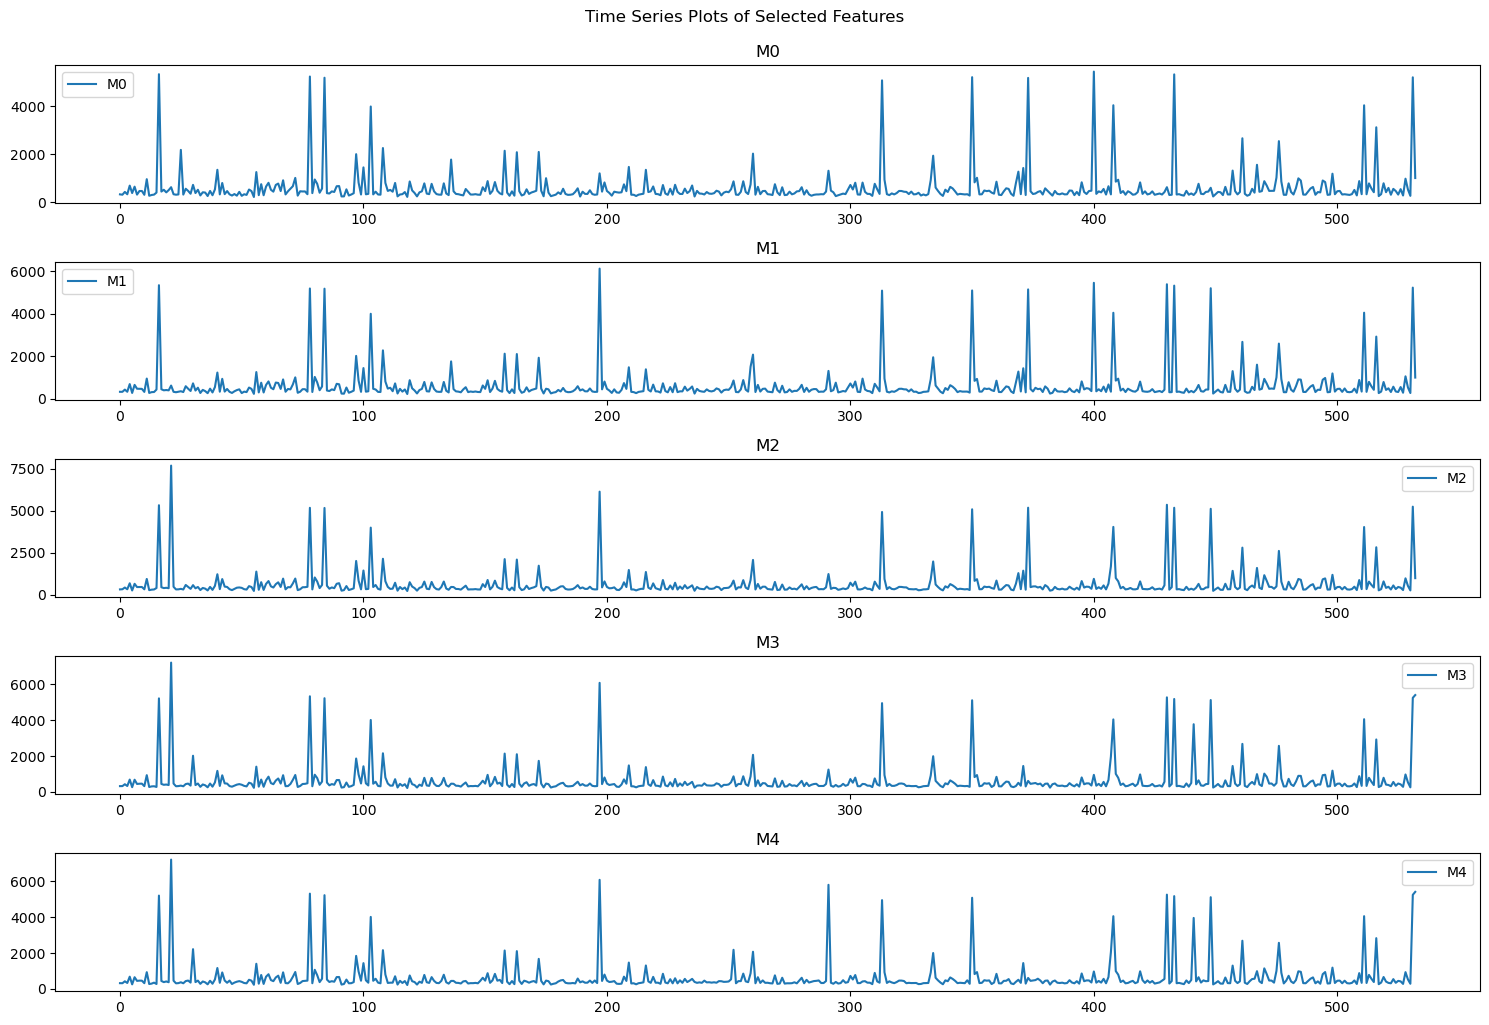

In [3]:
# Selecting a sample of features for time series plot (first 5 features)
time_series_features = df.columns[:5]

# Time Series Plot
plt.figure(figsize=(15, 10))
for i, feature in enumerate(time_series_features, 1):
    plt.subplot(len(time_series_features), 1, i)
    plt.plot(df[feature], label=feature)
    plt.title(feature)
    plt.legend()
    plt.tight_layout()

plt.suptitle("Time Series Plots of Selected Features", y=1.02)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Thesis\Time_Series_Plots.png', bbox_inches='tight')
plt.show()



### Box Plots for Anomaly Visualization

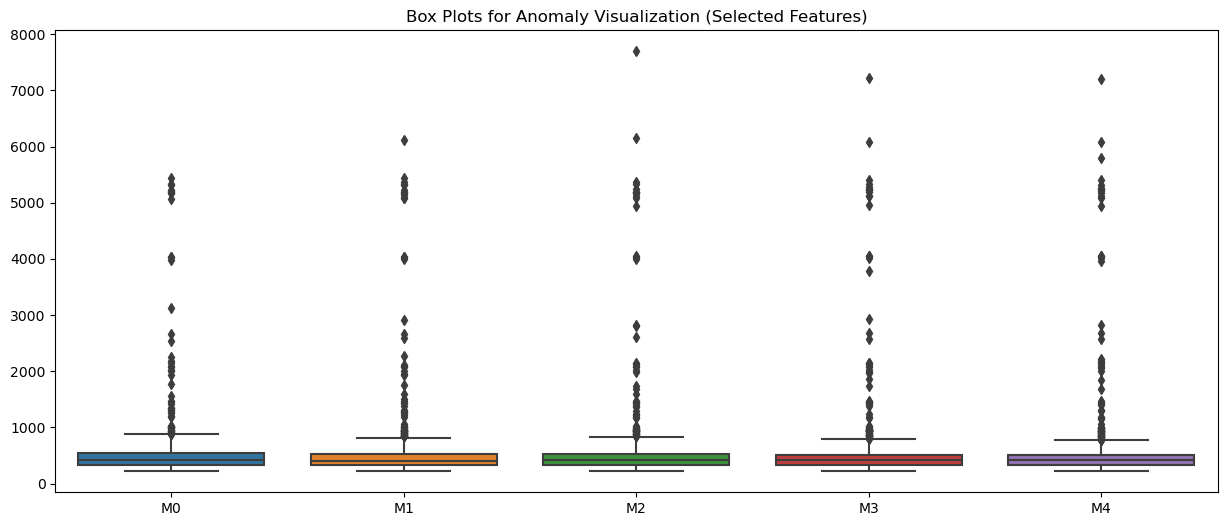

In [4]:
# Box Plots for Anomaly Visualization
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[time_series_features])
plt.title("Box Plots for Anomaly Visualization (Selected Features)")
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Thesis\Box_Plot_Anomaly.png', bbox_inches='tight')
plt.show()


### Histograms of Feature Distributions

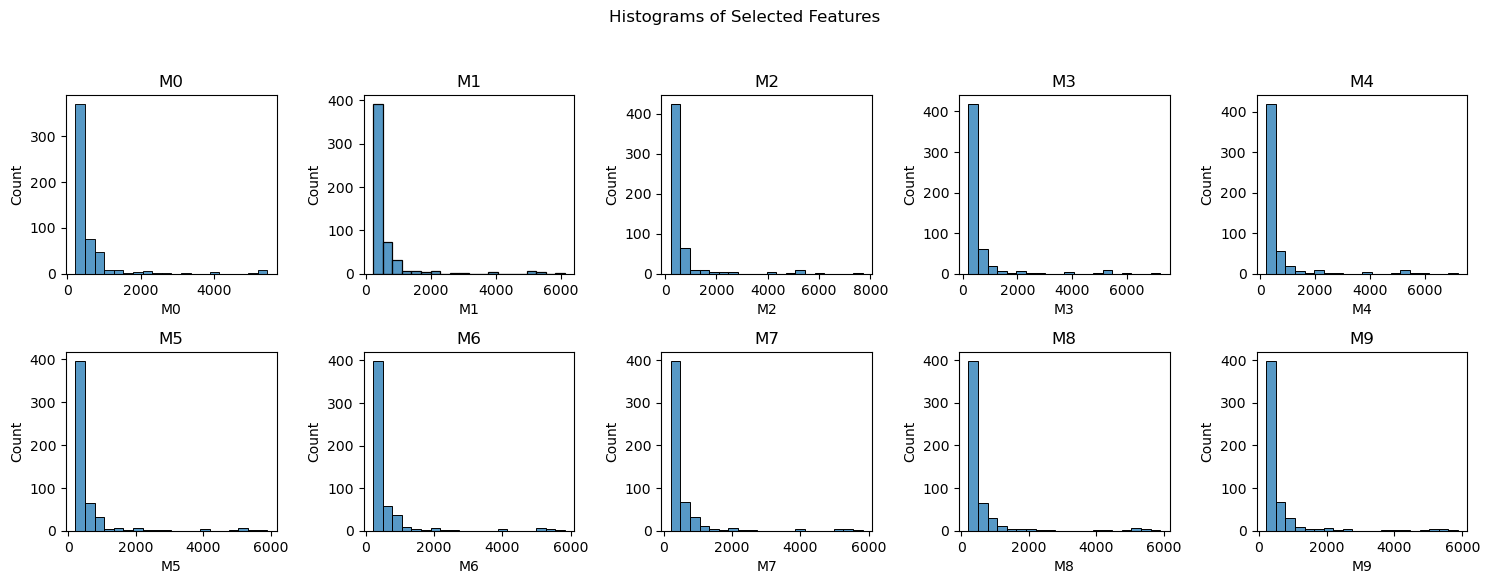

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Note: Replace 'your_data.csv' with the path to your dataset
# df = pd.read_csv('your_data.csv')

# Selecting a subset of features for visualization (first 20 features)
selected_features = df.columns[:10]

# Plotting histograms for the selected features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(selected_features, 1):
    plt.subplot(4, 5, i)
    sns.histplot(df[feature], bins=20, kde=False)
    plt.title(feature)
    plt.tight_layout()

plt.suptitle("Histograms of Selected Features", y=1.05)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Thesis\Histograms.png', bbox_inches='tight')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Thesis\Heatmap_ind.png', bbox_inches='tight')
plt.show()


### Heatmap of Correlation

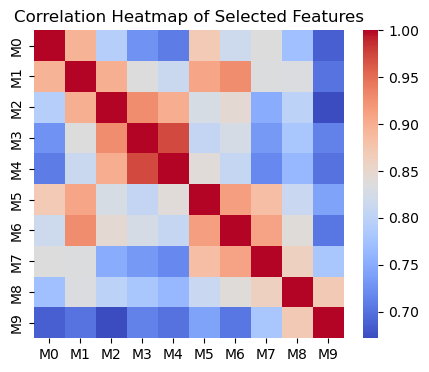

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
# Note: Replace 'your_data.csv' with the path to your dataset
# df = pd.read_csv('your_data.csv')

# Selecting a subset of features for correlation heatmap (first 20 features)
selected_features = df.columns[:10]

# Correlation heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(df[selected_features].corr(), annot=False, cmap='coolwarm')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Thesis\Heatmap.png', bbox_inches='tight')
plt.title("Correlation Heatmap of Selected Features")
plt.show()


### Hourly Consumption Pattern

In [7]:
# Re-importing pandas and reloading the dataset as the code execution state was reset
import pandas as pd

# Reload the smaller training dataset
# small_train_path = '/mnt/data/psa_journal_home_A_synthetic_train_small.csv'
# small_train_data = pd.read_csv(small_train_path)

train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_synthetic_train_small.csv"
# test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_sim_test.csv"
train_data = pd.read_csv(train_file_path)
# test_data = pd.read_csv(test_file_path)

# Assuming each feature represents a reading at regular intervals
# Aggregating every 60 features for an hourly sum

# Number of features to aggregate for an hour
features_per_hour = 60

# Total number of features in the dataset
# total_features = len(small_train_data.columns) - 1  # excluding the 'Label' column
total_features = len(train_data.columns) - 1  # excluding the 'Label' column

# Calculating the number of hourly aggregates we can create
num_hourly_aggregates = total_features // features_per_hour

# Creating hourly aggregated features
for i in range(num_hourly_aggregates):
    start_col = i * features_per_hour
    end_col = start_col + features_per_hour
#     small_train_data[f'Hourly_Sum_{i}'] = small_train_data.iloc[:, start_col:end_col].sum(axis=1)
    train_data[f'Hourly_Sum_{i}'] = train_data.iloc[:, start_col:end_col].sum(axis=1)

# Displaying the first few rows of the modified dataset with new hourly aggregated features
# small_train_data.head()
train_data.head()


,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,...,Hourly_Sum_13,Hourly_Sum_14,Hourly_Sum_15,Hourly_Sum_16,Hourly_Sum_17,Hourly_Sum_18,Hourly_Sum_19,Hourly_Sum_20,Hourly_Sum_21,Hourly_Sum_22
0,328,325,319,323,322,322,327,324,329,322,...,33653,42051,85492,22053,112277,72836,49840,31045,135169,89743
1,314,324,328,325,319,323,322,322,327,324,...,55299,58736,166960,21797,212357,119218,85376,30872,225176,126888
2,431,428,431,429,426,424,419,301,301,303,...,25168,28944,23386,28895,28610,20769,23107,20730,26389,56026
3,332,327,327,329,332,327,328,318,329,329,...,50022,28627,24497,64378,30778,115980,112892,29097,58397,55003
4,692,687,684,688,683,684,812,820,806,803,...,112982,28761,25914,125775,55803,26599,44104,53705,55356,32109


### Home A Hourly Dataset

In [8]:
import pandas as pd

# Load datasets
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_sim_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Assuming each feature represents a reading at regular intervals
# Aggregating every 60 features for an hourly sum
features_per_hour = 60

# Function to create hourly aggregates
def create_hourly_aggregates(df, features_per_hour):
    total_features = len(df.columns) - 1  # excluding the 'Label' column
    num_hourly_aggregates = total_features // features_per_hour

    for i in range(num_hourly_aggregates):
        start_col = i * features_per_hour
        end_col = start_col + features_per_hour
        df[f'Hourly_Sum_{i}'] = df.iloc[:, start_col:end_col].sum(axis=1)
    return df

# Apply the function to both datasets
train_data_aggregated = create_hourly_aggregates(train_data, features_per_hour)
test_data_aggregated = create_hourly_aggregates(test_data, features_per_hour)

# Displaying the first few rows of the modified datasets with new hourly aggregated features
print(train_data_aggregated.head())
print(test_data_aggregated.head())

# Save the modified datasets
train_data_aggregated.to_csv(r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_synthetic_train_hourly.csv", index=False)
test_data_aggregated.to_csv(r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_sim_test_hourly.csv", index=False)


    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  Hourly_Sum_13  \
0  328  325  319  323  322  322  327  324  329  322  ...          33653   
1  314  324  328  325  319  323  322  322  327  324  ...          55299   
2  431  428  431  429  426  424  419  301  301  303  ...          25168   
3  332  327  327  329  332  327  328  318  329  329  ...          50022   
4  692  687  684  688  683  684  812  820  806  803  ...         112982   

   Hourly_Sum_14  Hourly_Sum_15  Hourly_Sum_16  Hourly_Sum_17  Hourly_Sum_18  \
0          42051          85492          22053         112277          72836   
1          58736         166960          21797         212357         119218   
2          28944          23386          28895          28610          20769   
3          28627          24497          64378          30778         115980   
4          28761          25914         125775          55803          26599   

   Hourly_Sum_19  Hourly_Sum_20  Hourly_Sum_21  Hourly_Sum_22  
0   

### Home B Hourly Dataset

In [1]:
import pandas as pd

# Load datasets
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_B_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_B_sim_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Assuming each feature represents a reading at regular intervals
# Aggregating every 60 features for an hourly sum
features_per_hour = 60

# Function to create hourly aggregates
def create_hourly_aggregates(df, features_per_hour):
    total_features = len(df.columns) - 1  # excluding the 'Label' column
    num_hourly_aggregates = total_features // features_per_hour

    for i in range(num_hourly_aggregates):
        start_col = i * features_per_hour
        end_col = start_col + features_per_hour
        df[f'Hourly_Sum_{i}'] = df.iloc[:, start_col:end_col].sum(axis=1)
    return df

# Apply the function to both datasets
train_data_aggregated = create_hourly_aggregates(train_data, features_per_hour)
test_data_aggregated = create_hourly_aggregates(test_data, features_per_hour)

# Displaying the first few rows of the modified datasets with new hourly aggregated features
print(train_data_aggregated.head())
print(test_data_aggregated.head())

# Save the modified datasets
train_data_aggregated.to_csv(r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_B_synthetic_train_hourly.csv", index=False)
test_data_aggregated.to_csv(r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_B_sim_test_hourly.csv", index=False)

    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  Hourly_Sum_13  \
0  233  238  240  236  232  237  233  234  282  274  ...          19801   
1  448  448  440  446  469  447  448  448  444  448  ...          29331   
2  460  456  455  456  452  451  458  454  453  449  ...          22913   
3  362  360  361  363  339  339  330  339  340  339  ...          22451   
4  470  342  338  333  333  334  332  328  335  329  ...          25678   

   Hourly_Sum_14  Hourly_Sum_15  Hourly_Sum_16  Hourly_Sum_17  Hourly_Sum_18  \
0          17155          47279          27525          20309          91362   
1          25896          27486          26493          24226          22662   
2          21694          25670          32941          24460          22685   
3         110033          35673         112208          32619          48582   
4          24571          25016          25900          24910          42337   

   Hourly_Sum_19  Hourly_Sum_20  Hourly_Sum_21  Hourly_Sum_22  
0   

### Home C Hourly Dataset

In [2]:
import pandas as pd

# Load datasets
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_sim_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Assuming each feature represents a reading at regular intervals
# Aggregating every 60 features for an hourly sum
features_per_hour = 60

# Function to create hourly aggregates
def create_hourly_aggregates(df, features_per_hour):
    total_features = len(df.columns) - 1  # excluding the 'Label' column
    num_hourly_aggregates = total_features // features_per_hour

    for i in range(num_hourly_aggregates):
        start_col = i * features_per_hour
        end_col = start_col + features_per_hour
        df[f'Hourly_Sum_{i}'] = df.iloc[:, start_col:end_col].sum(axis=1)
    return df

# Apply the function to both datasets
train_data_aggregated = create_hourly_aggregates(train_data, features_per_hour)
test_data_aggregated = create_hourly_aggregates(test_data, features_per_hour)

# Displaying the first few rows of the modified datasets with new hourly aggregated features
print(train_data_aggregated.head())
print(test_data_aggregated.head())

# Save the modified datasets
train_data_aggregated.to_csv(r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_synthetic_train_hourly.csv", index=False)
test_data_aggregated.to_csv(r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_sim_test_hourly.csv", index=False)

    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  Hourly_Sum_13  \
0  603  595  594  598  597  402  448  444  454  444  ...          28739   
1  259  263  265  261  264  256  266  259  427  398  ...          26895   
2  368  367  367  367  369  509  508  487  495  496  ...          21174   
3  820  825  683  672  681  557  558  558  560  559  ...          39849   
4  247  244  246  246  243  243  233  243  246  241  ...          16234   

   Hourly_Sum_14  Hourly_Sum_15  Hourly_Sum_16  Hourly_Sum_17  Hourly_Sum_18  \
0          30253         101184         152106          23985          30702   
1          28989          33310          42674          42657          19413   
2          19349          20863          18762          36897          26481   
3         266062          41784          67504          87212          86972   
4          23877          41282          66120         219398          41927   

   Hourly_Sum_19  Hourly_Sum_20  Hourly_Sum_21  Hourly_Sum_22  
0   